In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
import random

In [2]:
X,Y = load_diabetes(return_X_y=True,as_frame=True)

In [4]:
X = X.values
Y = Y.values

In [5]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [6]:
from sklearn.linear_model import SGDRegressor

In [23]:
SGDR = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.3,early_stopping=False)

In [24]:
batch_size = 10
for i in range(100):
    idx = random.sample(range(X_train.shape[0]),batch_size)
    SGDR.partial_fit(X_train[idx],Y_train[idx])

In [25]:
r2 = r2_score(Y_test,SGDR.predict(X_test))
print(r2)

0.3965130487264962


In [26]:
#Bias - Variance Trade off

In [28]:
df = pd.read_csv("placement.csv")
X = df.iloc[:,0].values
Y = df.iloc[:,1].values

In [29]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [59]:
class BiasVariance:
    def __init__(self,epoch,lr_rate):
        self.epoch = epoch
        self.lr_rate = lr_rate
        self.bias_array = []
        self.variance_array = []

    def bias(self,X_train,Y_train):
        for i in range(self.epoch):
            sgd = SGDRegressor(max_iter=i+1,learning_rate='constant',eta0=self.lr_rate,early_stopping=True)
            sgd.fit(X_train.reshape(-1,1),Y_train)
            y_pred = sgd.predict(X_train.reshape(-1,1))
            r2 = r2_score(Y_train,y_pred)
            self.bias_array.append(r2)

        plt.xlabel("Epoch")
        plt.ylabel("$r_2 score$")
        plt.grid()
        plt.title("Bias Trend")
        plt.plot(range(1,self.epoch+1),self.bias_array)

    def variance(self,X_train,Y_train,X_test,Y_test):
        for i in range(self.epoch):
            sgd = SGDRegressor(max_iter=i+1,learning_rate='constant',eta0=self.lr_rate,early_stopping=True)
            sgd.fit(X_train.reshape(-1,1),Y_train)
            y_pred = sgd.predict(X_test.reshape(-1,1))
            var = np.var(y_pred)
            self.variance_array.append(var)
        plt.xlabel("Epoch")
        plt.ylabel("$variance$")
        plt.grid()
        plt.title("variance Trend")
        plt.plot(range(1,self.epoch+1),self.variance_array)

    def trade_off(self,X_train,Y_train,X_test,Y_test):
        plt.plot(np.linspace(1,self.epoch,self.epoch),self.bias_array,color = 'red')
        plt.plot(np.linspace(1,self.epoch,self.epoch),self.variance_array,color = 'green')

In [60]:
bvt = BiasVariance(30,0.005)

C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linea

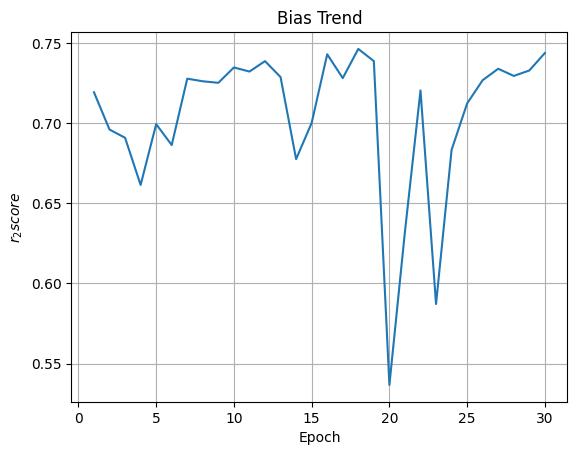

In [61]:
bvt.bias(X_train,Y_train)

C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\arnab\anaconda3\Lib\site-packages\sklearn\linea

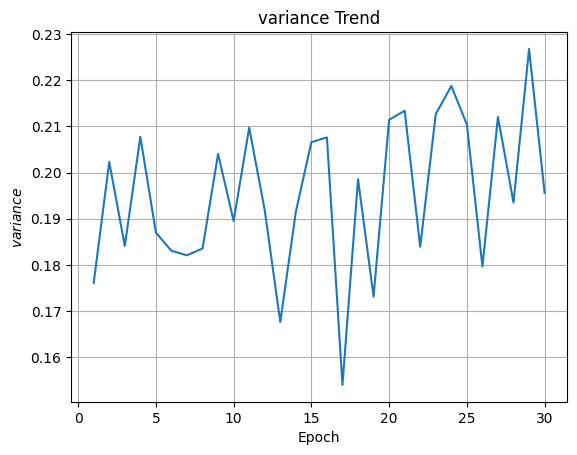

In [62]:
bvt.variance(X_train,Y_train,X_test,Y_test)

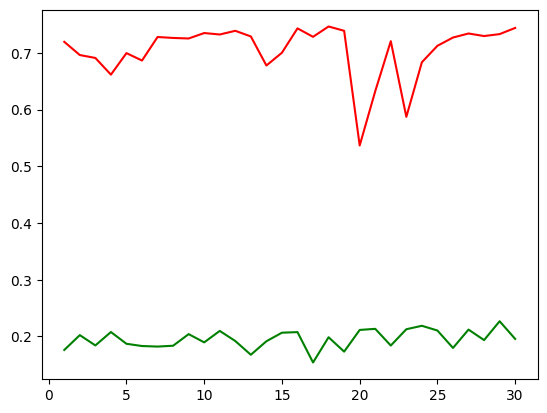

In [64]:
bvt.trade_off(X_train,Y_train,X_test,Y_test)